In [1]:
#IMPORTING LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#LOADING DATASET

df = pd.read_csv("NETTech Employee Salary.csv")
print(df.head())
print(df.shape)
print(df.info())

   Experience   Education    Skills  Department  Age  Salary
0          10    Master's      Java       Sales   34  439302
1          15     Diploma    Python  Operations   39  556083
2           9     Diploma    Python     Finance   34  412457
3           8         PhD  Power BI          IT   30  383540
4          11  Bachelor's      Java          HR   34  462967
(100, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Experience  100 non-null    int64 
 1   Education   100 non-null    object
 2   Skills      100 non-null    object
 3   Department  100 non-null    object
 4   Age         100 non-null    int64 
 5   Salary      100 non-null    int64 
dtypes: int64(3), object(3)
memory usage: 4.8+ KB
None


In [2]:
#DATA PREPROCESSING

print(df.isnull().sum())

from sklearn.preprocessing import LabelEncoder
le_edu = LabelEncoder()
le_dept = LabelEncoder()
le_skill = LabelEncoder()

df['Education_enc'] = le_edu.fit_transform(df['Education'])
df['Department_enc'] = le_dept.fit_transform(df['Department'])
df['Skills_enc'] = le_skill.fit_transform(df['Skills'])

X = df[['Experience','Age','Education_enc','Department_enc','Skills_enc']]
y = df['Salary']




Experience    0
Education     0
Skills        0
Department    0
Age           0
Salary        0
dtype: int64


In [3]:
#TRAINING, TESTING AND SPLITING

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state=42)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)


Train size: (80, 5)
Test size: (20, 5)


In [4]:
#MODEL TRAINING
#COMPARING THREE MODELS
             #--Linear Regression.
             #---Random Forest.
             #----Decision Tree.
             
from sklearn.linear_model import  LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

models = {
    "Linear Regression" : LinearRegression(),
    "Decision Tree" : DecisionTreeRegressor(random_state=42),
    "Random Forest" : RandomForestRegressor(random_state=42) 
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    results[name] = {
        "R2 score" : r2_score(y_test, preds),
        "MAE" : mean_absolute_error(y_test, preds),
        "RMSE" : np.sqrt(mean_squared_error(y_test, preds))
    }

    results_df = pd.DataFrame(results).T
    print(results_df)

                   R2 score          MAE          RMSE
Linear Regression  0.993827  9517.966273  10853.983315
                   R2 score           MAE          RMSE
Linear Regression  0.993827   9517.966273  10853.983315
Decision Tree      0.985332  13890.200000  16731.540446
                   R2 score           MAE          RMSE
Linear Regression  0.993827   9517.966273  10853.983315
Decision Tree      0.985332  13890.200000  16731.540446
Random Forest      0.990637  11180.378000  13367.940634


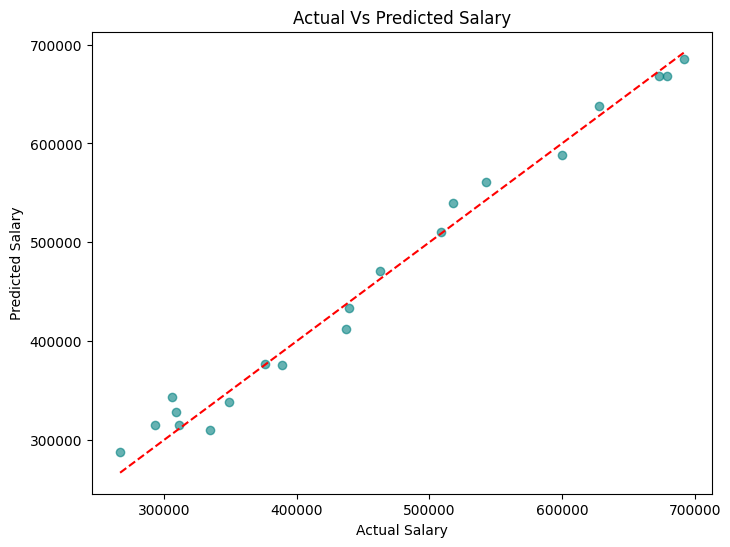

In [5]:
#GRAPH PLOTING

best_model = DecisionTreeRegressor(random_state=42)
best_model.fit(X_train, y_train)
preds = best_model.predict(X_test)

plt.figure(figsize=(8,6))
plt.scatter(y_test, preds, alpha=0.6, color='teal')
plt.plot([y_test.min(),y_test.max()], [y_test.min(),y_test.max()], 'r--')
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual Vs Predicted Salary")
plt.savefig("actual_vs_predicted.png")
plt.show()

In [6]:
import pickle

with open("salaray_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

with open("encoders.pkl", "wb") as f:
    pickle.dump({"education": le_edu, "department": le_dept, "skills": le_skill}, f)    

In [7]:
import pickle
test = pickle.load(open("encoders.pkl", "rb"))
print(test.keys())

dict_keys(['education', 'department', 'skills'])


In [8]:
import sklearn
print(sklearn.__version__)

1.3.2


In [9]:
!pip install --upgrade scikit-learn

   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.3 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.3 MB 479.2 kB/s eta 0:00:17
   -- ------------------------------------- 0.5/8.3 MB 479.2 kB/s eta 0:00:17
   -- ------------------------------------- 0.5/8.3 MB 479.2 kB/s eta 0:00:17
   -- ------------------------------------- 0.5/8.3 MB 479.2 kB/s eta 0:00:17
   --- ------------------------------------ 0.8/8.3 MB 390.1 kB/s eta 0:00:20
   --- ------------------------------------ 0.8/8.3 MB 390.1 kB/s eta 0:00:20
   --- ------------------------------------ 0.8/8.3 MB 390.1 kB/s eta 0:00:20
   ----- -------------------------------

  You can safely remove it manually.

[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip
